<a href="https://colab.research.google.com/github/akhilesh2009/Titanic---Machine-Learning-from-Disaster/blob/main/Titanic_Machine_Learning_from_Disaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Titanic - Machine Learning from Disaster**

**Importing required Libraries**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

**Reading the train dataset**

In [17]:
train = pd.read_csv("/content/drive/MyDrive/train.csv")
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [18]:
train.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886                              Montvila, Rev. Juozas    male  27.0      0   
887                       Graham, Miss. Margaret Edith  female  19.0      0   
888           Johnston, Miss. Catherine Helen "Carrie"  female   NaN      1   
889                              Behr, Mr. Karl Howell    male  26.0      0   
890                                Dooley, Mr. Patrick    male  32.0      0   

     Parch            Ticket     Fare Cabin Embarked  
0        0         A/5 21171   7.2500   NaN        S  
1        0          PC 17599  71.2833   C85        C  
2        0  STON/O2. 3101282   7.9250   NaN        S  
3        0            113803  53.1000  C123        S  
4        0            373450   8.0500   NaN        S  
..     ...               ...      ...   ...      ...  
886      0            211536  13.0000   NaN        S  
887      0            112053  30.0000   B42        S  
888      2        W./C. 6607  23.4500   NaN        S  
889      0            111369  30.0000  C148        C  
890      0            370376   7.7500   NaN        Q  

[891 rows x 12 columns]>

**Dropping useless columns**

In [19]:
clean_train = train.drop(["Ticket", "Cabin", "Fare", "Name"], axis=1)
clean_train

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,1,0,3,male,22.0,1,0,S
1,2,1,1,female,38.0,1,0,C
2,3,1,3,female,26.0,0,0,S
3,4,1,1,female,35.0,1,0,S
4,5,0,3,male,35.0,0,0,S
...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,S
887,888,1,1,female,19.0,0,0,S
888,889,0,3,female,NaN,1,2,S
889,890,1,1,male,26.0,0,0,C


**Missing/NaN values**

In [20]:
clean_train["Age"] = clean_train["Age"].fillna(clean_train.groupby("Pclass")["Age"].transform("median"))

In [21]:
clean_train

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,1,0,3,male,22.0,1,0,S
1,2,1,1,female,38.0,1,0,C
2,3,1,3,female,26.0,0,0,S
3,4,1,1,female,35.0,1,0,S
4,5,0,3,male,35.0,0,0,S
...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,S
887,888,1,1,female,19.0,0,0,S
888,889,0,3,female,24.0,1,2,S
889,890,1,1,male,26.0,0,0,C


In [22]:
clean_train[clean_train["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
61,62,1,1,female,38.0,0,0,NaN
829,830,1,1,female,62.0,0,0,NaN


**Data visualization**

<function matplotlib.pyplot.show(close=None, block=None)>

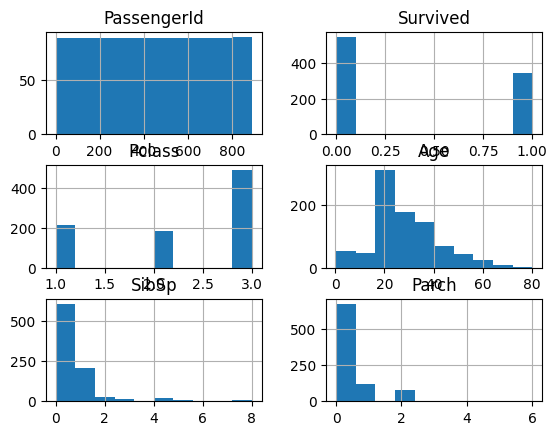

In [23]:
clean_train.hist()
plt.show

**Correlations**

In [24]:
clean_train_corr = clean_train.corr(numeric_only=True)
clean_train_corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch
PassengerId,1.000000,-0.005007,-0.035144,0.035840,-0.057527,-0.001652
Survived,-0.005007,1.000000,-0.338481,-0.047255,-0.035322,0.081629
Pclass,-0.035144,-0.338481,1.000000,-0.408487,0.083081,0.018443
Age,0.035840,-0.047255,-0.408487,1.000000,-0.243526,-0.171095
SibSp,-0.057527,-0.035322,0.083081,-0.243526,1.000000,0.414838
Parch,-0.001652,0.081629,0.018443,-0.171095,0.414838,1.000000


**Handling Text and Categorical Attributes**

In [25]:
ordinal_encoder = OrdinalEncoder()
categorical_cols_to_encode = ['Sex', 'Embarked']
clean_train_processed = clean_train.copy()
clean_train_processed[categorical_cols_to_encode] = ordinal_encoder.fit_transform(clean_train_processed[categorical_cols_to_encode])
clean_train_encoded = clean_train_processed
clean_train_encoded

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,1,0,3,1.0,22.0,1,0,2.0
1,2,1,1,0.0,38.0,1,0,0.0
2,3,1,3,0.0,26.0,0,0,2.0
3,4,1,1,0.0,35.0,1,0,2.0
4,5,0,3,1.0,35.0,0,0,2.0
...,...,...,...,...,...,...,...,...
886,887,0,2,1.0,27.0,0,0,2.0
887,888,1,1,0.0,19.0,0,0,2.0
888,889,0,3,0.0,24.0,1,2,2.0
889,890,1,1,1.0,26.0,0,0,0.0


Creating X(input) & y(output)

In [26]:
X = clean_train_encoded.drop("Survived", axis=1)
y = clean_train_encoded["Survived"]

**Splitting the train test data**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,random_state=42)

# **Using Decision Tree Classifier**

In [28]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

[Text(0.32501362645348836, 0.9736842105263158, 'x[2] <= 0.5\ngini = 0.469\nsamples = 712\nvalue = [444, 268]'),
 Text(0.1310562015503876, 0.9210526315789473, 'x[1] <= 2.5\ngini = 0.386\nsamples = 245\nvalue = [64, 181]'),
 Text(0.22803491400193798, 0.9473684210526316, 'True  '),
 Text(0.044573643410852716, 0.868421052631579, 'x[3] <= 2.5\ngini = 0.074\nsamples = 130\nvalue = [5, 125]'),
 Text(0.023255813953488372, 0.8157894736842105, 'x[1] <= 1.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.015503875968992248, 0.7631578947368421, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.031007751937984496, 0.7631578947368421, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.06589147286821706, 0.8157894736842105, 'x[0] <= 215.5\ngini = 0.061\nsamples = 128\nvalue = [4, 124]'),
 Text(0.046511627906976744, 0.7631578947368421, 'x[0] <= 198.0\ngini = 0.219\nsamples = 24\nvalue = [3, 21]'),
 Text(0.03875968992248062, 0.7105263157894737, 'x[3] <= 49.5\ngini = 0.159\nsamples = 23\nvalue = 

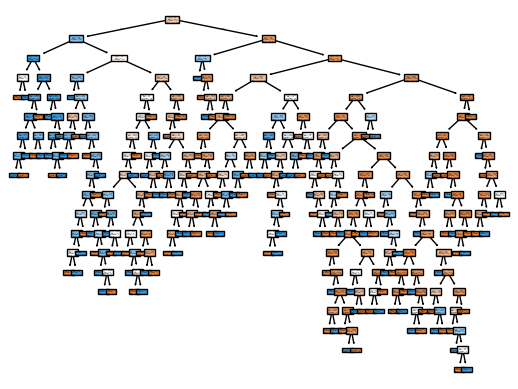

In [33]:
plot_tree(model, filled=True)

In [30]:
y_pred = model.predict(X_test)

**Model Accuracy**

In [31]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7486033519553073

# **Using Random Forest Model**

In [ ]:
rndf_model =